# Multimodal (audio-visual) analysis
> This script is running for experiment with auditory and visual (objects) trials.

In [ ]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size


dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice' : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)


[2026-05-24 12:15:33,348][WARNING]: Reconnecting to MySQL server.


OperationalError: (2003, "Can't connect to MySQL server on 'database.eflab.org' (timed out)")

In [8]:
# complete the key
animal_id = 328
from_session = 360
to_session = 500

# Distribution of each condition across sessions

In [9]:

restr = exp.Session() & {'animal_id': animal_id}
valid_sessions = (restr - exp.Session.Excluded).fetch('session')

sessions = []

auditory_pct = []
visual_pct = []
multimodal_pct = []

for session in range(from_session, to_session + 1):
    if session not in valid_sessions:
        continue

    key = {'animal_id': animal_id, "session":session}

    # auditory conditions = obj_mag = 0 & tone_volume > 0 ---------------------------------------------------------------
    auditory_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'state in ("Reward", "Punish")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    auditory_stateonset['obj_mag'] = pd.to_numeric(auditory_stateonset['obj_mag'], errors='coerce')
    auditory_stateonset = auditory_stateonset[auditory_stateonset['obj_mag'] == 0]

    # visual conditions = obj_mag > 0 & tone_volume = 0 ---------------------------------------------------------------
    visual_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume = 0'
        & key
        & 'state in ("Reward", "Punish")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    visual_stateonset['obj_mag'] = pd.to_numeric(visual_stateonset['obj_mag'], errors='coerce')
    visual_stateonset = visual_stateonset[visual_stateonset['obj_mag'] > 0]

    # multimodal conditions = obj_mag > 0 & tone_volume > 0 ---------------------------------------------------------------
    multi_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'state in ("Reward", "Punish")'
        # & 'state in ("Abort")'
    ).fetch(format='frame').reset_index()
    
    multi_stateonset['obj_mag'] = pd.to_numeric(multi_stateonset['obj_mag'], errors='coerce')
    multi_stateonset = multi_stateonset[multi_stateonset['obj_mag'] > 0]


    # ---- replace with real per-session computation ----
    auditory_trials = len(auditory_stateonset)
    visual_trials = len(visual_stateonset)
    multimodal_trials = len(multi_stateonset)

    sizes = np.array([auditory_trials, visual_trials, multimodal_trials])
    total = sizes.sum()

    if total == 0:
        continue

    sessions.append(session)
    auditory_pct.append(sizes[0] / total * 100)
    visual_pct.append(sizes[1] / total * 100)
    multimodal_pct.append(sizes[2] / total * 100)

# convert to numpy arrays (IMPORTANT for alignment)
auditory_pct = np.array(auditory_pct)
visual_pct = np.array(visual_pct)
multimodal_pct = np.array(multimodal_pct)

y = np.arange(len(sessions))  # <-- THIS fixes alignment

plt.figure(figsize=(10, max(4, len(sessions) * 0.3)))

plt.barh(y, auditory_pct, label='Auditory')
plt.barh(y, visual_pct, left=auditory_pct, label='Visual')
plt.barh(y, multimodal_pct, left=auditory_pct + visual_pct, label='Multimodal')

plt.yticks(y, sessions)   # <-- correct session labels aligned to bars

plt.xticks(range(0, 101, 5))
plt.xlabel('Percentage')
plt.ylabel('Session ID')
plt.title(f'Trial Modality Distribution (Animal {animal_id})')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

[2026-05-24 12:15:17,445][WARNING]: Reconnecting to MySQL server.


OperationalError: (2003, "Can't connect to MySQL server on 'database.eflab.org' (timed out)")

## Scatter plot beetween modalites across sessions

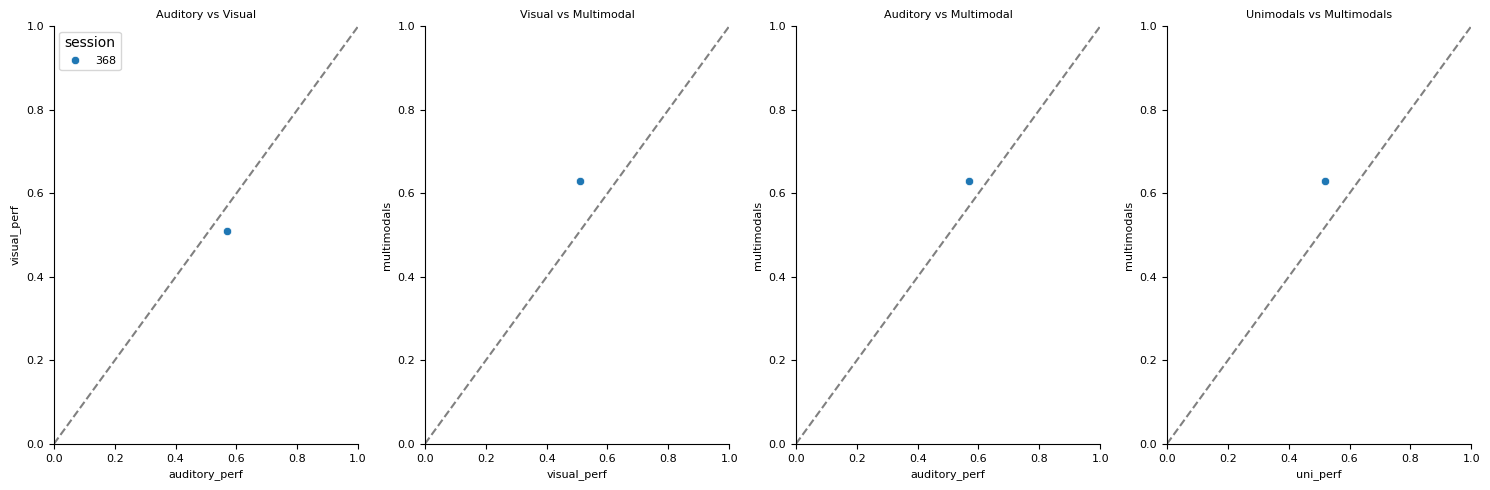

Skipped sessions (missing one or more modalities): [360, 361, 363]


,session,auditory_perf,visual_perf,multi_perf,uni_perf
0,368,0.57,0.51,0.63,0.52


In [4]:
restr = exp.Session() & {'animal_id': animal_id}
valid_sessions = (restr - exp.Session.Excluded).fetch('session')

perf_per_condition = []
skipped_sessions = []

for session in range(from_session, to_session + 1):
    if session not in valid_sessions:
        continue

    key = {'animal_id': animal_id, "session":session}

    # auditory conditions = obj_mag = 0 & tone_volume > 0
    auditory_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    auditory_stateonset['obj_mag'] = pd.to_numeric(auditory_stateonset['obj_mag'], errors='coerce')
    auditory_stateonset = auditory_stateonset[auditory_stateonset['obj_mag'] == 0]

    # visual conditions = obj_mag > 0 & tone_volume = 0
    visual_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume = 0'
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    visual_stateonset['obj_mag'] = pd.to_numeric(visual_stateonset['obj_mag'], errors='coerce')
    visual_stateonset = visual_stateonset[visual_stateonset['obj_mag'] > 0]

    # multimodal conditions = obj_mag > 0 & tone_volume > 0
    multi_stateonset = (
        stim.StimCondition.Trial * 
        (stim.Panda.Object).proj('obj_mag') * 
        exp.Trial.StateOnset * 
        (stim.Tones).proj('tone_volume') 
        & 'tone_volume > 0'
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    multi_stateonset['obj_mag'] = pd.to_numeric(multi_stateonset['obj_mag'], errors='coerce')
    multi_stateonset = multi_stateonset[multi_stateonset['obj_mag'] > 0]

    # # only unimodal trials (both auditory and visual)
    # unimodal_stateonset = (
    # stim.StimCondition.Trial *
    # (stim.Panda.Object).proj('obj_mag') *
    # exp.Trial.StateOnset *
    # (stim.Tones).proj('tone_volume')
    # & key
    # & 'state in ("Reward", "Punish")'
    # & '((obj_mag > 0 AND tone_volume = 0) OR (obj_mag = 0 AND tone_volume > 0))'
    # ).fetch(format='frame').reset_index()
    
    # unimodal_stateonset['obj_mag'] = pd.to_numeric(unimodal_stateonset['obj_mag'], errors='coerce')
    # unimodal_stateonset = unimodal_stateonset[unimodal_stateonset['obj_mag'] > 0]

    unimodal_stateonset = (
        stim.StimCondition.Trial *
        (stim.Panda.Object).proj('obj_mag') *
        exp.Trial.StateOnset *
        (stim.Tones).proj('tone_volume')
        & key
        & 'state in ("Reward", "Punish")'
    ).fetch(format='frame').reset_index()
    
    # convert safely
    unimodal_stateonset['obj_mag'] = pd.to_numeric(
        unimodal_stateonset['obj_mag'],
        errors='coerce'
    )
    
    unimodal_stateonset['tone_volume'] = pd.to_numeric(
        unimodal_stateonset['tone_volume'],
        errors='coerce'
    )
    
    # apply the OR condition in pandas
    unimodal_stateonset = unimodal_stateonset[
        (
            (unimodal_stateonset['obj_mag'] > 0) &
            (unimodal_stateonset['tone_volume'] == 0)
        )
        |
        (
            (unimodal_stateonset['obj_mag'] == 0) &
            (unimodal_stateonset['tone_volume'] > 0)
        )
    ]


     # Skip sessions missing ANY modality
    if (
        len(auditory_stateonset) == 0 or
        len(visual_stateonset) == 0 or
        len(multi_stateonset) == 0
    ):
        skipped_sessions.append(session)
        continue

    # Calculate the performance in each condition
    visual_perf = round((visual_stateonset['state'] == 'Reward').mean(), 2)
    auditory_perf = round((auditory_stateonset['state'] == 'Reward').mean(), 2)
    multi_perf = round((multi_stateonset['state'] == 'Reward').mean(), 2)
    uni_perf = round((unimodal_stateonset['state'] == 'Reward').mean(), 2)

    perf_per_condition.append({
        'session': session,
        'auditory_perf': auditory_perf,
        'visual_perf': visual_perf,
        'multi_perf': multi_perf,
        'uni_perf': uni_perf,
    })
    
perf_per_condition = pd.DataFrame(perf_per_condition)

perf_per_condition['session'] = perf_per_condition['session'].astype(str)

# plotting =======================
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=False)

# Auditory vs Visual
sns.scatterplot(
    data=perf_per_condition,
    x='auditory_perf',
    y='visual_perf',
    ax=axes[0],
    hue='session'
)
axes[0].set_title('Auditory vs Visual')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axline((0, 0), slope=1, linestyle='--', color='gray')

# Visual vs Multimodal
sns.scatterplot(
    data=perf_per_condition,
    x='visual_perf',
    y='multi_perf',
    ax=axes[1],
    hue='session',
    legend=False
)
axes[1].set_title('Visual vs Multimodal')
axes[1].set_ylabel('multimodals')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axline((0, 0), slope=1, linestyle='--', color='gray')

# Auditory vs Multimodal
sns.scatterplot(
    data=perf_per_condition,
    x='auditory_perf',
    y='multi_perf',
    ax=axes[2],
    hue='session',
    legend=False
)
axes[2].set_title('Auditory vs Multimodal')
axes[2].set_ylabel('multimodals')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].axline((0, 0), slope=1, linestyle='--', color='gray')

# Unimodals vs Multimodal
sns.scatterplot(
    data=perf_per_condition,
    x='uni_perf',
    y='multi_perf',
    ax=axes[3],
    hue='session',
    legend=False
)
axes[3].set_title('Unimodals vs Multimodals')
axes[3].set_ylabel('multimodals')
axes[3].set_xlim(0, 1)
axes[3].set_ylim(0, 1)
axes[3].axline((0, 0), slope=1, linestyle='--', color='gray')


plt.tight_layout()
plt.show()


print("Skipped sessions (missing one or more modalities):", skipped_sessions)
display(perf_per_condition)

In [5]:
## Statistical significant difference between conditions (paired t-test)

# Per object ID analysis

In [ ]:
from multimodal_analysis.multimodal_functions import visual_df, plot_visual_performance

key = {
    'animal_id': animal_id,
    'sessions': (from_session, to_session), # define the session range (from_session, to_session)
    'difficulties': [2, 0, 0, 0], # define the difficulties
    'object_ids': [211,212,213,214,215,216,217,218,219], # define the obj_ids that you want
    'excluded_sessions': [] #define the sessions that you want to exclude from the analysis
}

Object 212:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,328,368,2026-05-22 12:00:01,1153,58,0.48,28,30,119


Object 213:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,328,368,2026-05-22 12:00:01,1153,46,0.24,11,35,105


Object 218:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,328,368,2026-05-22 12:00:01,1153,50,0.76,38,12,85


Object 219:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,328,368,2026-05-22 12:00:01,1153,38,0.53,20,18,74


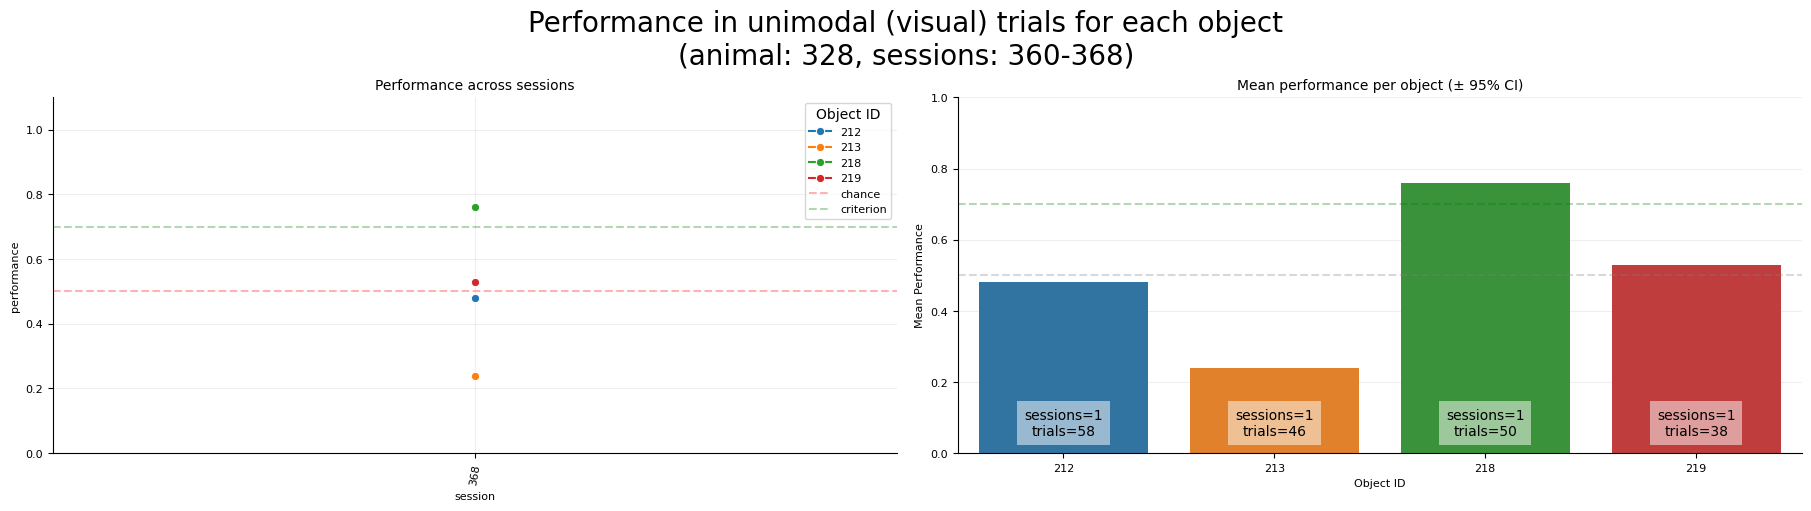

In [7]:
dfs = visual_df(key)
plot_visual_performance(key)